In [3]:
import os
import time
import random
import warnings
from datetime import date
import gc

import numpy as np
import pandas as pd
import pyarrow as pa
import pyarrow.parquet as pq
from lxml import etree # type: ignore <- pylance milně hlásí chybu
from pathlib import Path
import time
import sys
import polars as pl
import polars.selectors as cs
import json
import pickle
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import matplotlib.patheffects as path_effects
from ydata_profiling import ProfileReport
import geopandas as gpd


current_dir = Path(__file__).resolve().parent if "__file__" in locals() else Path.cwd()
sys.path.append(str(current_dir.parent))
from utils import *
from schemas import *
from clean import *
from visualisation_utils import *

pl.Config.set_tbl_cols(-1)
os.chdir(r'E:\CVUT_BAP')
# os.chdir(r'C:\Users\adamp\Projects\CVUT_BAP')
SEED=42
PRINT = False
DATA_PATH = r"kod\data\processed\mereni.parquet"
TEMP_PATH = r"kod\data\processed\mereni.tmp.parquet"

# Načtení dat

In [2]:
df = pl.read_parquet(r'kod\data\extracted\data_z_mericich_pristroju\parquet', schema=mereni_schema)
if PRINT: describe(df, True)

# Přetypování sloupců

In [3]:
df = cast_mereni(df)

# Vyber mereni, ktera maji protejsek v prohlidkach (zajisteni stejnych filtru)

In [ ]:
lf_prohlidky = pl.scan_parquet(r'kod\data\processed\prohlidky.parquet')
id_prohlidky_series = lf_prohlidky.select('CisloProtokolu').unique().collect(engine='streaming').get_column('CisloProtokolu')

if PRINT:
    id_prohlidky = set(id_prohlidky_series)
    id_mereni = set(df.get_column('CisloProtokolu'))
    orphan = list(id_prohlidky - id_mereni)
    lf_prohlidky.filter(pl.col('CisloProtokolu').is_in(orphan)).collect(engine='streaming')['DatumProhlidky'].value_counts(sort=True)

df = df.join(id_prohlidky_series.to_frame("CisloProtokolu"), on="CisloProtokolu", how="semi")

# Odstraneni nekterych sloupcu
### Rok_vyroby

In [5]:
if PRINT: print(f'Podil mereni, ktera maji rok vyroby mensi nez 1000: {len(df.filter(pl.col('Vozidlo_RokVyroby') < 1000)) / df.height * 100:.2f} %')

### Vysledek_RidiciJednotka

In [6]:
if PRINT: 
    print(df.select('Vysledek_RidiciJednotkaStav', 'Vysledek_RidiciJednotka').filter(pl.col('Vysledek_RidiciJednotkaStav') == 1)['Vysledek_RidiciJednotka'].value_counts(sort=True)['Vysledek_RidiciJednotka'].to_list()[:10])
    print(df.select('Vysledek_RidiciJednotkaStav', 'Vysledek_RidiciJednotka').filter(pl.col('Vysledek_RidiciJednotkaStav') == 2)['Vysledek_RidiciJednotka'].value_counts(sort=True)['Vysledek_RidiciJednotka'].to_list()[:10])
    print(df.select('Vysledek_RidiciJednotkaStav', 'Vysledek_RidiciJednotka').filter(pl.col('Vysledek_RidiciJednotkaStav') == 3)['Vysledek_RidiciJednotka'].value_counts(sort=True)['Vysledek_RidiciJednotka'].to_list()[:10])

### Obd_VypisDTC

In [7]:
if PRINT: 
    obd_vypis_dtc_non_null = df['Obd_VypisDtc'].filter(df['Obd_VypisDtc'].is_not_null())
    print(f'Podil, kdy obd vypis dtc neni null: {len(obd_vypis_dtc_non_null) / df.height * 100:.2f} %')
    print(obd_vypis_dtc_non_null.to_list()[:10])

### J1939
- Odstraneni radku, ktere hodnoty obsahuji

In [8]:
j1939_df = df.filter(
    pl.any_horizontal(
        pl.col("^.*J1939.*$").is_not_null()
    )
)
if PRINT: short_display(j1939_df)
# Modifikace df
df = df.join(j1939_df, on="CisloProtokolu", how="anti")

### Plyn_PocetVyusteni

In [9]:
if PRINT: df['Plyn_PocetVyusteni'].value_counts()

### PristiProhlidka

In [10]:
if PRINT: df.filter(pl.col('PristiProhlidka').is_not_null())['Vysledek_Vyhovuje'].value_counts()

In [11]:
duplicate_cols = ['DatumProhlidky', 'Zahajeni', 'Ukonceni', 'OdpovednaOsoba', 'Prohlidka_DatumProhlidky', 'Vozidlo_Vin', 'Vozidlo_Znacka', 'Vozidlo_ObchodniOznaceni', 'Vozidlo_TypMotoru', 'Vozidlo_CisloMotoru', 'Vozidlo_Odometer', 'Vozidlo_DatumPrvniRegistrace', 'Vozidlo_Palivo', 'Obd_Vin']
irrelevant_cols = ['Prohlidka_CisloProtokolu', 'Vozidlo_RokVyroby', 'Vysledek_RidiciJednotka', 'Vysledek_TesnostPlynovehoZarizeni', 'PristiProhlidka', 'Benzin_Palivo', 'Nafta_Palivo']
j1939_cols = ['Obd_Readiness_J1939_AC_Podporovano', 'Obd_Readiness_J1939_AC_Otestovano', 'Obd_Readiness_J1939_BOOST_Podporovano', 'Obd_Readiness_J1939_BOOST_Otestovano', 'Obd_Readiness_J1939_CAT-FUNC_Podporovano', 'Obd_Readiness_J1939_CAT-FUNC_Otestovano', 'Obd_Readiness_J1939_COLD_Podporovano', 'Obd_Readiness_J1939_COLD_Otestovano', 'Obd_Readiness_J1939_COMP_Podporovano', 'Obd_Readiness_J1939_COMP_Otestovano', 'Obd_Readiness_J1939_DPF_Podporovano', 'Obd_Readiness_J1939_DPF_Otestovano', 'Obd_Readiness_J1939_EGR-VVT_Podporovano', 'Obd_Readiness_J1939_EGR-VVT_Otestovano', 'Obd_Readiness_J1939_EGS-FUNC_Podporovano', 'Obd_Readiness_J1939_EGS-FUNC_Otestovano', 'Obd_Readiness_J1939_EGS-HEAT_Podporovano', 'Obd_Readiness_J1939_EGS-HEAT_Otestovano', 'Obd_Readiness_J1939_EVAP_Podporovano', 'Obd_Readiness_J1939_EVAP_Otestovano', 'Obd_Readiness_J1939_FUEL_Podporovano', 'Obd_Readiness_J1939_FUEL_Otestovano', 'Obd_Readiness_J1939_HCAT_Podporovano', 'Obd_Readiness_J1939_HCAT_Otestovano', 'Obd_Readiness_J1939_MISF_Podporovano', 'Obd_Readiness_J1939_MISF_Otestovano', 'Obd_Readiness_J1939_NM-HC_Podporovano', 'Obd_Readiness_J1939_NM-HC_Otestovano', 'Obd_Readiness_J1939_NOX_Podporovano', 'Obd_Readiness_J1939_NOX_Otestovano', 'Obd_Readiness_J1939_SAS_Podporovano', 'Obd_Readiness_J1939_SAS_Otestovano']
plyn_cols = ['Plyn_Palivo', 'Plyn_PocetVyusteni', 'Plyn_OtackyVolnobezne_CO_Max_Hodnota', 'Plyn_OtackyVolnobezne_CO_Max_RucniZadani', 'Plyn_OtackyVolnobezne_CO_Hodnota', 'Plyn_OtackyVolnobezne_CO_Vysledek', 'Plyn_OtackyVolnobezne_CO2_Hodnota', 'Plyn_OtackyVolnobezne_CO2_Vysledek', 'Plyn_OtackyVolnobezne_COCOOR_Hodnota', 'Plyn_OtackyVolnobezne_COCOOR_Vysledek', 'Plyn_OtackyVolnobezne_HC_Max_Hodnota', 'Plyn_OtackyVolnobezne_HC_Max_RucniZadani', 'Plyn_OtackyVolnobezne_HC_Hodnota', 'Plyn_OtackyVolnobezne_HC_Vysledek', 'Plyn_OtackyVolnobezne_LAMBDA_Min_Hodnota', 'Plyn_OtackyVolnobezne_LAMBDA_Min_RucniZadani', 'Plyn_OtackyVolnobezne_LAMBDA_Max_Hodnota', 'Plyn_OtackyVolnobezne_LAMBDA_Max_RucniZadani', 'Plyn_OtackyVolnobezne_LAMBDA_Hodnota', 'Plyn_OtackyVolnobezne_LAMBDA_Vysledek', 'Plyn_OtackyVolnobezne_N_Min_Hodnota', 'Plyn_OtackyVolnobezne_N_Min_RucniZadani', 'Plyn_OtackyVolnobezne_N_Max_Hodnota', 'Plyn_OtackyVolnobezne_N_Max_RucniZadani', 'Plyn_OtackyVolnobezne_N_Hodnota', 'Plyn_OtackyVolnobezne_N_Vysledek', 'Plyn_OtackyVolnobezne_NOX_Hodnota', 'Plyn_OtackyVolnobezne_NOX_Vysledek', 'Plyn_OtackyVolnobezne_O2_Hodnota', 'Plyn_OtackyVolnobezne_O2_Vysledek', 'Plyn_OtackyVolnobezne_TPS_Hodnota', 'Plyn_OtackyVolnobezne_TPS_Vysledek', 'Plyn_OtackyZvysene_CO_Max_Hodnota', 'Plyn_OtackyZvysene_CO_Max_RucniZadani', 'Plyn_OtackyZvysene_CO_Hodnota', 'Plyn_OtackyZvysene_CO_Vysledek', 'Plyn_OtackyZvysene_CO2_Hodnota', 'Plyn_OtackyZvysene_CO2_Vysledek', 'Plyn_OtackyZvysene_COCOOR_Hodnota', 'Plyn_OtackyZvysene_COCOOR_Vysledek', 'Plyn_OtackyZvysene_HC_Max_Hodnota', 'Plyn_OtackyZvysene_HC_Max_RucniZadani', 'Plyn_OtackyZvysene_HC_Hodnota', 'Plyn_OtackyZvysene_HC_Vysledek', 'Plyn_OtackyZvysene_LAMBDA_Min_Hodnota', 'Plyn_OtackyZvysene_LAMBDA_Min_RucniZadani', 'Plyn_OtackyZvysene_LAMBDA_Max_Hodnota', 'Plyn_OtackyZvysene_LAMBDA_Max_RucniZadani', 'Plyn_OtackyZvysene_LAMBDA_Hodnota', 'Plyn_OtackyZvysene_LAMBDA_Vysledek', 'Plyn_OtackyZvysene_N_Min_Hodnota', 'Plyn_OtackyZvysene_N_Min_RucniZadani', 'Plyn_OtackyZvysene_N_Max_Hodnota', 'Plyn_OtackyZvysene_N_Max_RucniZadani', 'Plyn_OtackyZvysene_N_Hodnota', 'Plyn_OtackyZvysene_N_Vysledek', 'Plyn_OtackyZvysene_NOX_Hodnota', 'Plyn_OtackyZvysene_NOX_Vysledek', 'Plyn_OtackyZvysene_O2_Hodnota', 'Plyn_OtackyZvysene_O2_Vysledek', 'Plyn_OtackyZvysene_TPS_Hodnota', 'Plyn_OtackyZvysene_TPS_Vysledek', 'Plyn_Nadrz_Vyrobce', 'Plyn_Nadrz_Homologace', 'Plyn_Nadrz_Zivotnost', 'Plyn_Nadrz_Kontrola']
df = df.drop(duplicate_cols + irrelevant_cols + j1939_cols + plyn_cols)

# Unikatnost cisla protokolu
- nasledne odstraneno stanice cislo

In [13]:
if PRINT: print(f'Délka datasetu před odstraněním duplicitních řádků: {df.height}')

df = df.unique()
if PRINT: print(f'Délka datasetu po odstranění duplicitních řádků: {df.height}')

non_unique = df.select(pl.col('CisloProtokolu')).filter(pl.col('CisloProtokolu').is_duplicated())['CisloProtokolu'].unique().to_list()
if PRINT: short_display(df.filter(pl.col('CisloProtokolu').is_in(non_unique)).sort(by=['CisloProtokolu', 'StaniceCislo']))

df = df.filter(~pl.col('CisloProtokolu').is_in(non_unique) | (pl.col('CisloProtokolu').str.split('-').list.get(1).cast(pl.Int32) == pl.col("StaniceCislo")))
if PRINT: print(f'Délka datasetu po odstranění vsech duplicitnich cisel protokolu: {df.height}')
df = df.drop('StaniceCislo')

# Serazeni sloupcu podle textu prace

In [14]:
df = df.select([
    # Identifikace měření
    "CisloProtokolu",

    # Měřicí přístroj
    "MericiPristroj_Vyrobce",
    "MericiPristroj_Typ",
    "MericiPristroj_Verze",
    "MericiPristroj_OBD",
    "MericiPristroj_VerzeSoftware",

    # Výsledek měření
    "Vysledek_VisualniKontrola",
    "Vysledek_Readiness",
    "Vysledek_RidiciJednotkaStav",
    "Vysledek_Mil",
    "Vysledek_Vyhovuje",
    "Obd_Readiness_Vysledek",
    "Zavady",
    "Poznamky",

    # Emisní systém (rizenyOBD)
    "EmisniSystem",
    "Obd_KomunikacniProtokol",
    "Obd_KontrolaMil",
    "Obd_PocetDtc",
    "Obd_VypisDtc",
    "Obd_VzdalenostDtc",
    "Obd_CasDtc",
    *sorted([c for c in df.columns if "Obd_Readiness_Zazeh" in c]),
    *sorted([c for c in df.columns if "Obd_Readiness_Vznet" in c]),

    # Detail měření dle typu paliva - Benzin
    "Benzin_PocetVyusteni",
    *sorted([c for c in df.columns if c.startswith("Benzin_OtackyVolnobezne")]),
    *sorted([c for c in df.columns if c.startswith("Benzin_OtackyZvysene")]),

    # Detail měření dle typu paliva - Nafta
    "Nafta_PocetVyusteni",
    *sorted([c for c in df.columns if c.startswith("Nafta_MereniVznetLimit")]),
    *sorted([c for c in df.columns if c.startswith("Nafta_MereniPrumer")]),
    *sorted([c for c in df.columns if c.startswith("Nafta_Mereni0")]),
    *sorted([c for c in df.columns if c.startswith("Nafta_Mereni1")]),
    *sorted([c for c in df.columns if c.startswith("Nafta_Mereni2")]),
    *sorted([c for c in df.columns if c.startswith("Nafta_Mereni3")])
])

In [ ]:
if PRINT: schema_description(df)
df.write_parquet(r"kod\data\processed\mereni_tmp.parquet")

# Chybejici hodnoty

In [16]:
if PRINT: 
    # Definice agregačních skupin
    aggregation_groups = {
        'Obd_Readiness_Zazeh': [c for c in df.columns if 'Obd_Readiness_Zazeh' in c],
        'Obd_Readiness_Vznet': [c for c in df.columns if 'Obd_Readiness_Vznet' in c],
        'Benzin_OtackyVolnobezne': [c for c in df.columns if c.startswith('Benzin_OtackyVolnobezne_')],
        'Benzin_OtackyZvysene': [c for c in df.columns if c.startswith('Benzin_OtackyZvysene_')],
        'Nafta_MereniVznetLimit': [c for c in df.columns if c.startswith('Nafta_MereniVznetLimit_')],
        'Nafta_MereniPrumer': [c for c in df.columns if c.startswith('Nafta_MereniPrumer_')],
        'Nafta_Mereni0': [c for c in df.columns if c.startswith('Nafta_Mereni0_')],
        'Nafta_Mereni1': [c for c in df.columns if c.startswith('Nafta_Mereni1_')],
        'Nafta_Mereni2': [c for c in df.columns if c.startswith('Nafta_Mereni2_')],
        'Nafta_Mereni3': [c for c in df.columns if c.startswith('Nafta_Mereni3_')],
    }

    # Inverzní mapování: sloupec -> název skupiny
    col_to_group = {col: g_name for g_name, g_cols in aggregation_groups.items() for col in g_cols}

    # Výpočet metrik se zachováním pořadí z df.columns
    total_rows = len(df)
    final_labels = []
    final_ratios = []
    processed_groups = set()

    for col in df.columns:
        if col in col_to_group:
            group_name = col_to_group[col]
            if group_name not in processed_groups:
                # Výpočet pro celou skupinu (aspoň jedna ne-null hodnota)
                group_cols = aggregation_groups[group_name]
                any_present_count = df.select(
                    pl.any_horizontal(pl.col(group_cols).is_not_null())
                ).sum().item()
                final_labels.append(group_name)
                final_ratios.append(any_present_count / total_rows if total_rows > 0 else 0)
                processed_groups.add(group_name)
        else:
            # Samostatný sloupec
            non_null_count = total_rows - df[col].null_count()
            final_labels.append(col)
            final_ratios.append(non_null_count / total_rows if total_rows > 0 else 0)

    # Kategorizace (6 skupin včetně Vozidla)
    group_descriptions = [
        'Identifikace měření',
        'Měřicí přístroj',
        'Výsledek',  
        'Emisní systém', 
        'Detail měření'  
    ]

    def map_to_main_category(label):
        if label == 'CisloProtokolu': return 0
        if label.startswith('MericiPristroj'): return 1
        if any(x in label for x in ['Vysledek', 'PristiProhlidka', 'Zavady', 'Poznamky']): return 2
        if label.startswith('EmisniSystem') or label.startswith('Obd'): return 3
        if label.startswith('Benzin') or label.startswith('Nafta'): return 4
        return 3

    group_indices = [map_to_main_category(l) for l in final_labels]

    # Generování grafu
    horizontal_bar(
        labels=final_labels, 
        counts=final_ratios, 
        title='Poměr přítomných údajů v měřeních', 
        save_path='kod/explorace/mereni_grafy/mereni_pritomnost.svg', 
        decimals=3, 
        height=18, 
        group_indices=group_indices, 
        group_descriptions=group_descriptions
    )

### Emisni systemy

In [17]:
if PRINT: df['EmisniSystem'].value_counts(sort=True).with_columns(pl.col('count') / df.height)

### Pocet mereni u nafty

In [18]:
if PRINT: 
    print(f'Pomer dieselu, co ma alespon 2 mereni: {0.264 / 0.456 * 100:.2f} %')
    print(f'Pomer dieselu, co ma 3 a 4 mereni: {0.146 / 0.456 * 100:.2f} %')

# Ulozeni dat

In [ ]:
df.write_parquet(DATA_PATH)

In [84]:
df = pl.read_parquet(DATA_PATH)

# Odstraneni chybnych zaznamu
## Zaporne hodnoty

In [85]:
if PRINT: print(f'Pocet zaznamu se zapornou hodnou {df.filter(pl.any_horizontal(cs.numeric() < 0)).height}')
df = df.filter(pl.any_horizontal(~(cs.numeric() < 0)))

## Filtrace zaznamu predstavujicich konkretni mereni pro benzin nebo naftu

In [86]:
required_benzin = [
    # Benzin Vždy (Volnoběžné)
    "Benzin_OtackyVolnobezne_CO_Hodnota",
    "Benzin_OtackyVolnobezne_CO_Max_Hodnota",
    "Benzin_OtackyVolnobezne_N_Hodnota",
    "Benzin_OtackyVolnobezne_N_Min_Hodnota",
    "Benzin_OtackyVolnobezne_N_Max_Hodnota",
    
    # Benzin Zvýšené
    "Benzin_OtackyZvysene_LAMBDA_Hodnota",
    "Benzin_OtackyZvysene_LAMBDA_Min_Hodnota",
    "Benzin_OtackyZvysene_LAMBDA_Max_Hodnota",
    "Benzin_OtackyZvysene_CO_Max_Hodnota",
    "Benzin_OtackyZvysene_N_Hodnota",
    "Benzin_OtackyZvysene_N_Min_Hodnota",
    "Benzin_OtackyZvysene_N_Max_Hodnota"
]

required_nafta = [
    # Nafta Průměr
    "Nafta_MereniPrumer_CasAkcelerace_Hodnota",
    "Nafta_MereniPrumer_Kourivost_Hodnota",
    "Nafta_MereniPrumer_OtackyVolnobezne_Hodnota",
    "Nafta_MereniPrumer_OtackyPrebehove_Hodnota",
    
    # Nafta Limit Max
    "Nafta_MereniVznetLimit_CasAkcelerace_Max_Hodnota",
    "Nafta_MereniVznetLimit_Kourivost_Max_Hodnota",
    "Nafta_MereniVznetLimit_OtackyVolnobezne_Max_Hodnota",
    "Nafta_MereniVznetLimit_OtackyPrebehove_Max_Hodnota",
    
    # Nafta Limit Min
    "Nafta_MereniVznetLimit_OtackyVolnobezne_Min_Hodnota",
    "Nafta_MereniVznetLimit_OtackyPrebehove_Min_Hodnota"
]

benzin_mask = pl.all_horizontal(pl.col(required_benzin).is_not_null())
nafta_mask = pl.all_horizontal(pl.col(required_nafta).is_not_null())
if PRINT:
    print(f'Pocet neuplnych zaznamu: {df.filter(~(benzin_mask | nafta_mask)).height}')
    print(f'Pocet zaznamu s benzinem i naftou: {df.filter((pl.col('Nafta_PocetVyusteni') > 0) & (pl.col('Benzin_PocetVyusteni') > 0)).height}')
df = df.filter(benzin_mask | nafta_mask)

## Kontrola limitu
### Benzin

In [87]:
limits_bounds_benzin = [
    # (Název atributu limitu, Očekávané MIN limitu, Očekávané MAX limitu)
    ('Benzin_OtackyVolnobezne_CO_Max_Hodnota', 0.05, 5.0),
    ('Benzin_OtackyVolnobezne_N_Min_Hodnota', 300, 3000),
    ('Benzin_OtackyVolnobezne_N_Max_Hodnota', 300, 3000),
    ('Benzin_OtackyZvysene_CO_Max_Hodnota', 0.1, 1.0),
    ('Benzin_OtackyZvysene_LAMBDA_Min_Hodnota', 0.9, 1.00),
    ('Benzin_OtackyZvysene_LAMBDA_Max_Hodnota', 1.00, 1.1),
    ('Benzin_OtackyZvysene_N_Min_Hodnota', 1000, 10000),
    ('Benzin_OtackyZvysene_N_Max_Hodnota', 1000, 10000)
]

for limit_bound in limits_bounds_benzin:
    if PRINT: print(f'Pocet hodnot mimo limit pro {limit_bound[0]}: {df.filter(~pl.col(limit_bound[0]).is_between(limit_bound[1], limit_bound[2])).height}')
    df = df.filter(pl.col(limit_bound[0]).is_between(limit_bound[1], limit_bound[2]) | nafta_mask)

### Nafta

In [88]:
limits_bounds_nafta = [
    # (Název atributu limitu, Očekávané MIN limitu, Očekávané MAX limitu)
    ('Nafta_MereniVznetLimit_CasAkcelerace_Max_Hodnota', 0.1, 10.0),
    ('Nafta_MereniVznetLimit_Kourivost_Max_Hodnota', 0.1, 3.0),
    ('Nafta_MereniVznetLimit_OtackyVolnobezne_Min_Hodnota', 300, 3000),
    ('Nafta_MereniVznetLimit_OtackyVolnobezne_Max_Hodnota', 300, 3000),
    ('Nafta_MereniVznetLimit_OtackyPrebehove_Min_Hodnota', 1000, 10000),
    ('Nafta_MereniVznetLimit_OtackyPrebehove_Max_Hodnota', 1000, 10000)
]

for limit_bound in limits_bounds_nafta:
    if PRINT: print(f'Pocet hodnot mimo limit pro {limit_bound[0]}: {df.filter(~pl.col(limit_bound[0]).is_between(limit_bound[1], limit_bound[2])).height}')
    df = df.filter(pl.col(limit_bound[0]).is_between(limit_bound[1], limit_bound[2]) | benzin_mask)

### Nesmyslne delky intervalu

In [89]:
# Seznam dvojic limitů pro kontrolu integrity
check_limits_integrity = [
    ("Benzin_OtackyVolnobezne_N_Min_Hodnota", "Benzin_OtackyVolnobezne_N_Max_Hodnota"),
    ("Benzin_OtackyZvysene_LAMBDA_Min_Hodnota", "Benzin_OtackyZvysene_LAMBDA_Max_Hodnota"),
    ("Benzin_OtackyZvysene_N_Min_Hodnota", "Benzin_OtackyZvysene_N_Max_Hodnota"),
    ("Nafta_MereniVznetLimit_OtackyVolnobezne_Min_Hodnota", "Nafta_MereniVznetLimit_OtackyVolnobezne_Max_Hodnota"),
    ("Nafta_MereniVznetLimit_OtackyPrebehove_Min_Hodnota", "Nafta_MereniVznetLimit_OtackyPrebehove_Max_Hodnota")
]

for min_col, max_col in check_limits_integrity:
    if PRINT: print(f'Pocet hodnot se zapornou nebo nulovou delkou intervalu {min_col}, {max_col}: {df.filter(pl.col(min_col) >= pl.col(max_col)).height}')
    df = df.filter((pl.col(min_col).ne(pl.col(max_col))).fill_null(True))

## Pro dalsi analyzu uvazovany pouze Rizene emisni systemy
- odstraneny i zaznamy, ktere maji skoro same null (pro analyzu vsak mene relevantni - pouze jako vysledek)
- diky tomu neni mereno HC

In [90]:
if PRINT: print(f'Podil rizenych: {df['EmisniSystem'].value_counts().filter(pl.col('EmisniSystem').cast(pl.String).str.contains('Rizeny'))['count'].sum() / df.height * 100:.2f} %')
df = df.filter(pl.col('EmisniSystem').cast(pl.String).str.contains('Rizeny'))
# EmisniSystem uz obsahoval pouze 2 hodnoty
df = df.with_columns(pl.col('EmisniSystem') == 'Rizeny_Obd').rename({'EmisniSystem': 'OBD_Pritomno'})

## Filtrace pouze uspesnych mereni

In [91]:
if PRINT: print(f'Podil uspesnych: {df.filter(pl.col('Vysledek_Vyhovuje') == True).height / df.height * 100:.2f} %')
df = df.filter(pl.col('Vysledek_Vyhovuje') == True).drop('Vysledek_Vyhovuje')

# Extrakce dulezitych informaci

## Normalizace hodnot

In [92]:
# Definice mapování pro normalizaci
all_mappings = [
    ("Benzin_OtackyVolnobezne_CO_Hodnota", None, "Benzin_OtackyVolnobezne_CO_Max_Hodnota"),
    ("Benzin_OtackyVolnobezne_N_Hodnota", "Benzin_OtackyVolnobezne_N_Min_Hodnota", "Benzin_OtackyVolnobezne_N_Max_Hodnota"),
    ("Benzin_OtackyZvysene_LAMBDA_Hodnota", "Benzin_OtackyZvysene_LAMBDA_Min_Hodnota", "Benzin_OtackyZvysene_LAMBDA_Max_Hodnota"),
    ("Benzin_OtackyZvysene_CO_Hodnota", None, "Benzin_OtackyZvysene_CO_Max_Hodnota"),
    ("Benzin_OtackyZvysene_N_Hodnota", "Benzin_OtackyZvysene_N_Min_Hodnota", "Benzin_OtackyZvysene_N_Max_Hodnota"),
    ("Nafta_MereniPrumer_CasAkcelerace_Hodnota", None, "Nafta_MereniVznetLimit_CasAkcelerace_Max_Hodnota"),
    ("Nafta_MereniPrumer_Kourivost_Hodnota", None, "Nafta_MereniVznetLimit_Kourivost_Max_Hodnota"),
    ("Nafta_MereniPrumer_OtackyVolnobezne_Hodnota", "Nafta_MereniVznetLimit_OtackyVolnobezne_Min_Hodnota", "Nafta_MereniVznetLimit_OtackyVolnobezne_Max_Hodnota"),
    ("Nafta_MereniPrumer_OtackyPrebehove_Hodnota", "Nafta_MereniVznetLimit_OtackyPrebehove_Min_Hodnota", "Nafta_MereniVznetLimit_OtackyPrebehove_Max_Hodnota")
]

exprs = []
for val_col, min_col, max_col in all_mappings:
    low = pl.col(min_col) if min_col else pl.lit(0)
    high = pl.col(max_col)
    val = pl.col(val_col)
    
    # Normalizace
    norm_expr = ((val - low) / (high - low)).alias(f"{val_col}_Norm")
    exprs.append(norm_expr)

df = df.with_columns(exprs).drop((cs.starts_with('Benzin_') | cs.starts_with('Nafta_')) & (~cs.ends_with('PocetVyusteni')) & (~cs.ends_with('_Norm')))

## Spojeni informaci o mericim pristroji do Vyrobce a Typu

In [93]:
df = df.with_columns((pl.col('MericiPristroj_Vyrobce') + pl.col('MericiPristroj_Typ')).alias('MericiPristroj_Info')).drop(cs.contains("MericiPristroj") & (~cs.by_name("MericiPristroj_Info")))

## Pro nizkou ruznorodost ponechano pouze Obd_PocetDtc z DTC

In [94]:
df = df.drop(cs.contains('Dtc') & (~cs.by_name('Obd_PocetDtc')))

## Readiness podpory a otestovani prevedeno do poctu True

In [95]:
df = df.with_columns(pl.sum_horizontal(cs.ends_with("_Podporovano")).alias("Pocet_Podporovano"), pl.sum_horizontal(cs.ends_with("_Otestovano")).alias("Pocet_Otestovano"))
df = df.drop((cs.ends_with("_Podporovano") | cs.ends_with("_Otestovano")) & (~cs.by_name("Pocet_Podporovano")) & (~cs.by_name("Pocet_Otestovano")))

## Redukce seznamů na pocet prvku

In [96]:
df = df.with_columns(pl.col('Poznamky').list.len().fill_null(0), pl.col('Zavady').list.len().fill_null(0))

## Ulozeni mezivypoctu

In [97]:
df.write_parquet(r"kod\data\processed\mereni_small.parquet")

# Analyza zpracovaneho datasetu

In [98]:
PRINT=True
df = pl.read_parquet(r'kod/data/processed/mereni_small.parquet')
df_benzin = df.filter(pl.col('Benzin_PocetVyusteni') > 0).select(cs.ends_with('_Norm') & cs.starts_with('Benzin_'))
df_nafta = df.filter(pl.col('Nafta_PocetVyusteni') > 0).select(cs.ends_with('_Norm') & cs.starts_with('Nafta_'))

## Rozdeleni a prazdne hodnoty

In [99]:
if PRINT:
    display(df_benzin.describe())
    display(df_nafta.describe())

statistic,Benzin_OtackyVolnobezne_CO_Hodnota_Norm,Benzin_OtackyVolnobezne_N_Hodnota_Norm,Benzin_OtackyZvysene_LAMBDA_Hodnota_Norm,Benzin_OtackyZvysene_CO_Hodnota_Norm,Benzin_OtackyZvysene_N_Hodnota_Norm
str,f64,f64,f64,f64,f64
"""count""",8.454012e6,8.454012e6,8.454012e6,8.454012e6,8.454012e6
"""null_count""",0.0,0.0,0.0,0.0,0.0
"""mean""",0.129253,0.513828,0.605711,0.326995,0.465718
"""std""",0.521483,0.228209,11.609933,0.40097,0.30136
"""min""",-0.54,-15.5,-33.000031,-0.2,-40.0
"""25%""",0.0,0.4,0.483334,0.05,0.255
"""50%""",0.036667,0.5,0.55,0.2,0.455
"""75%""",0.16,0.608,0.683334,0.566667,0.665
"""max""",920.0,144.5,17050.517578,633.333313,100.900002


statistic,Nafta_MereniPrumer_CasAkcelerace_Hodnota_Norm,Nafta_MereniPrumer_Kourivost_Hodnota_Norm,Nafta_MereniPrumer_OtackyVolnobezne_Hodnota_Norm,Nafta_MereniPrumer_OtackyPrebehove_Hodnota_Norm
str,f64,f64,f64,f64
"""count""",6.942917e6,6.942917e6,6.942917e6,6.942917e6
"""null_count""",0.0,0.0,0.0,0.0
"""mean""",0.202997,0.288755,0.441056,0.471806
"""std""",0.268626,3.782765,0.35275,0.782809
"""min""",0.0,0.0,-37.0,-103.0
"""25%""",0.0,0.019608,0.306667,0.3625
"""50%""",0.188,0.155556,0.493333,0.5025
"""75%""",0.31,0.52,0.54,0.65
"""max""",400.0,9236.363281,77.0,220.399994


## Hodnoty mimo rozsah

In [100]:
def values_invalid(df):
    for col in df.columns:
        print(f'Relativni cetnost pozorovani {col} mimo rozsah <0, 1>: {df.filter(~pl.col(col).is_between(0, 1)).height / df.height * 100:.2f} %')

if PRINT:
    values_invalid(df_benzin)
    values_invalid(df_nafta)

Relativni cetnost pozorovani Benzin_OtackyVolnobezne_CO_Hodnota_Norm mimo rozsah <0, 1>: 0.00 %
Relativni cetnost pozorovani Benzin_OtackyVolnobezne_N_Hodnota_Norm mimo rozsah <0, 1>: 1.17 %
Relativni cetnost pozorovani Benzin_OtackyZvysene_LAMBDA_Hodnota_Norm mimo rozsah <0, 1>: 0.01 %
Relativni cetnost pozorovani Benzin_OtackyZvysene_CO_Hodnota_Norm mimo rozsah <0, 1>: 0.01 %
Relativni cetnost pozorovani Benzin_OtackyZvysene_N_Hodnota_Norm mimo rozsah <0, 1>: 3.38 %
Relativni cetnost pozorovani Nafta_MereniPrumer_CasAkcelerace_Hodnota_Norm mimo rozsah <0, 1>: 0.06 %
Relativni cetnost pozorovani Nafta_MereniPrumer_Kourivost_Hodnota_Norm mimo rozsah <0, 1>: 0.02 %
Relativni cetnost pozorovani Nafta_MereniPrumer_OtackyVolnobezne_Hodnota_Norm mimo rozsah <0, 1>: 0.82 %
Relativni cetnost pozorovani Nafta_MereniPrumer_OtackyPrebehove_Hodnota_Norm mimo rozsah <0, 1>: 1.73 %


### Nekdy je to zpusobeno spatnym zaokrouhlenim, jindy ne

In [101]:
if PRINT:
    df_kourivost_mimo = df.filter(~pl.col('Nafta_MereniPrumer_Kourivost_Hodnota_Norm').is_between(0, 1))
    short_display(df_kourivost_mimo)
    example_ids = df_kourivost_mimo['CisloProtokolu'][:10].to_list()
    short_display(pl.scan_parquet(r'kod\data\extracted\data_z_mericich_pristroju\parquet', schema=mereni_schema).select(pl.col('CisloProtokolu'), pl.col('^.*Kourivost.*$')).filter(pl.col('CisloProtokolu').is_in(example_ids)).collect(engine='streaming'))

(1074, 26)


,CisloProtokolu,Vysledek_VisualniKontrola,Vysledek_Readiness,Vysledek_RidiciJednotkaStav,Vysledek_Mil,Obd_Readiness_Vysledek,Zavady,Poznamky,OBD_Pritomno,Obd_KomunikacniProtokol,...,Benzin_OtackyZvysene_LAMBDA_Hodnota_Norm,Benzin_OtackyZvysene_CO_Hodnota_Norm,Benzin_OtackyZvysene_N_Hodnota_Norm,Nafta_MereniPrumer_CasAkcelerace_Hodnota_Norm,Nafta_MereniPrumer_Kourivost_Hodnota_Norm,Nafta_MereniPrumer_OtackyVolnobezne_Hodnota_Norm,Nafta_MereniPrumer_OtackyPrebehove_Hodnota_Norm,MericiPristroj_Info,Pocet_Podporovano,Pocet_Otestovano
0,CZ-520402-19-09-0004,True,None,NaN,NaN,None,0,1,False,None,...,NaN,NaN,NaN,0.000000,1.160256,0.340000,0.466667,BOSCHBEA070,0,0
1,CZ-472201-19-10-0281,True,True,NaN,2.0,None,0,3,False,None,...,NaN,NaN,NaN,0.348000,1.066667,0.306667,0.215000,BoschMTM-BEA,0,0
2,CZ-120301-21-06-0325,True,True,1.0,2.0,True,0,2,True,ISO 9141,...,NaN,NaN,NaN,0.000000,2.727273,0.500000,0.800000,AVL DiTEST GmbHAVL DiSmoke 480,2,11
3,CZ-410946-24-10-0211,True,True,1.0,2.0,True,0,2,True,ISO 14230-4 (ISO OBD,...,NaN,NaN,NaN,0.518000,1.200000,0.350000,0.396667,MAHLEOPA-100,3,11
4,CZ-580904-22-08-0201,True,True,1.0,2.0,True,0,5,True,ISO 15765,...,NaN,NaN,NaN,0.304000,1.061538,0.500000,0.732143,AVL DiTEST GmbHAVL DiSmoke 480,2,11
5,CZ-410946-24-10-0253,True,True,1.0,2.0,True,0,2,True,ISO 15765-4 (CAN OBD,...,NaN,NaN,NaN,0.682000,1.040000,0.540000,0.500000,MAHLEOPA-100,1,11
6,CZ-560505-25-11-0055,True,False,3.0,2.0,False,0,2,True,ISO 14230 (KWP 2000 Fast),...,NaN,NaN,NaN,0.348000,3.960784,0.230000,0.500000,ATAL s.r.o.AT605,3,11
7,CZ-530203-19-11-0230,True,True,1.0,2.0,True,0,1,True,ISO 15765,...,NaN,NaN,NaN,0.430000,1.600000,0.750000,0.183333,AVL DiTEST GmbHAVL DiSmoke 480,1,11
8,CZ-420338-23-11-0326,True,True,1.0,2.0,True,0,4,True,ISO 9141,...,NaN,NaN,NaN,0.585000,1.018182,0.750000,0.525000,AVL DiTEST GmbHAVL DiSmoke 480,2,11
9,CZ-480117-19-04-0037,True,True,1.0,2.0,True,1,2,True,ISO 15765,...,NaN,NaN,NaN,0.000000,1.568627,0.900000,0.350000,AVL DiTEST GmbHAVL DiSmoke 480,5,11


(10, 15)


,CisloProtokolu,Nafta_MereniVznetLimit_Kourivost_Max_Hodnota,Nafta_MereniVznetLimit_Kourivost_Max_RucniZadani,Nafta_MereniVznetLimit_KourivostRozpeti_Max_Hodnota,Nafta_MereniVznetLimit_KourivostRozpeti_Max_RucniZadani,Nafta_MereniPrumer_Kourivost_Hodnota,Nafta_MereniPrumer_Kourivost_Vysledek,Nafta_Mereni0_Kourivost_Hodnota,Nafta_Mereni0_Kourivost_Vysledek,Nafta_Mereni1_Kourivost_Hodnota,Nafta_Mereni1_Kourivost_Vysledek,Nafta_Mereni2_Kourivost_Hodnota,Nafta_Mereni2_Kourivost_Vysledek,Nafta_Mereni3_Kourivost_Hodnota,Nafta_Mereni3_Kourivost_Vysledek
0,CZ-480117-19-04-0037,0.51,true,0.25,true,0.8,1,0.78,1,None,None,None,None,None,None
1,CZ-520402-19-09-0004,1.560,false,0.250,false,1.81,0,0.42,1,0.41,1,0.4,1,0.4,1
2,CZ-560505-25-11-0055,0.510,0,0.250,0,2.02,0,3.23,0,0.0,1,2.58,0,2.28,0
3,CZ-420338-23-11-0326,1.10,false,0.25,false,1.12,1,1.1,1,1.13,1,None,None,None,None
4,CZ-120301-21-06-0325,0.11,true,0.25,true,0.3,1,0.24,1,0.36,1,None,None,None,None
5,CZ-530203-19-11-0230,0.25,false,0.25,false,0.4,1,0.03,1,0.76,1,None,None,None,None
6,CZ-472201-19-10-0281,0.90,false,0.25,false,0.96,1,1.04,1,1.07,1,0.95,1,0.78,1
7,CZ-410946-24-10-0211,0.70,true,0.25,true,0.84,1,0.89,1,0.79,1,None,None,None,None
8,CZ-580904-22-08-0201,1.30,true,0.25,false,1.38,1,1.28,1,1.34,1,1.42,1,1.48,1
9,CZ-410946-24-10-0253,0.50,true,0.25,true,0.52,1,0.46,1,0.57,1,None,None,None,None


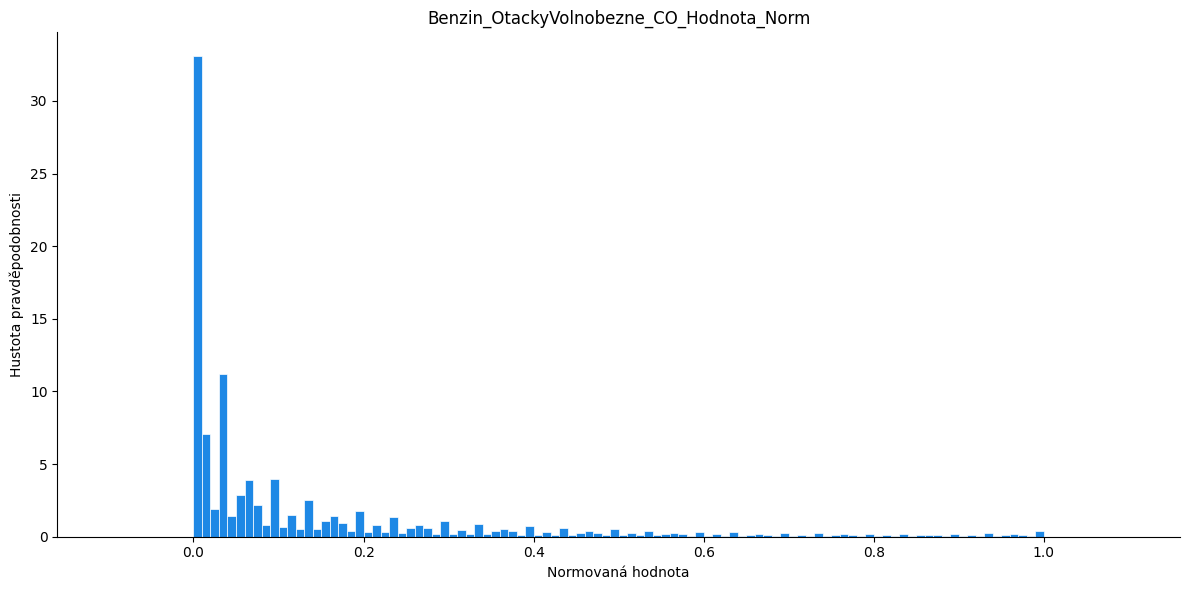

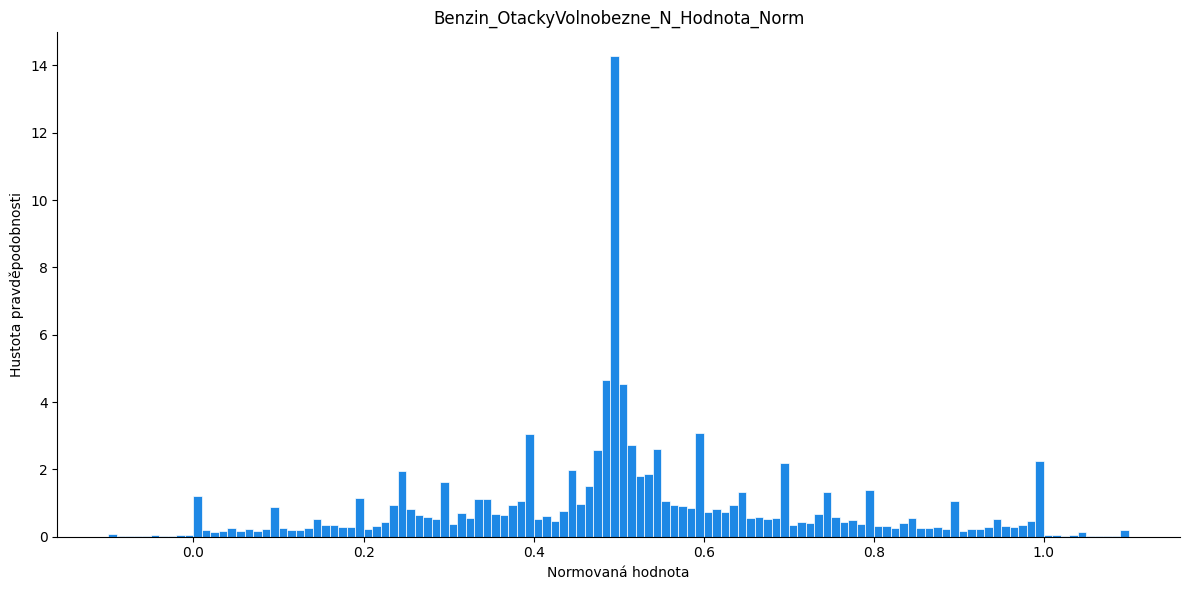

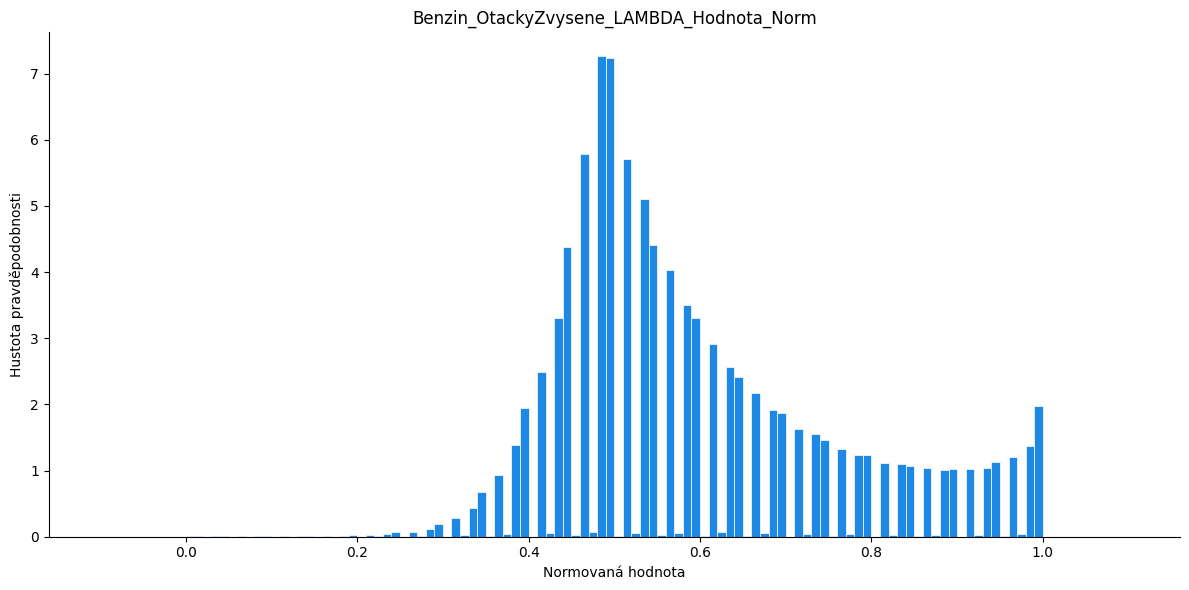

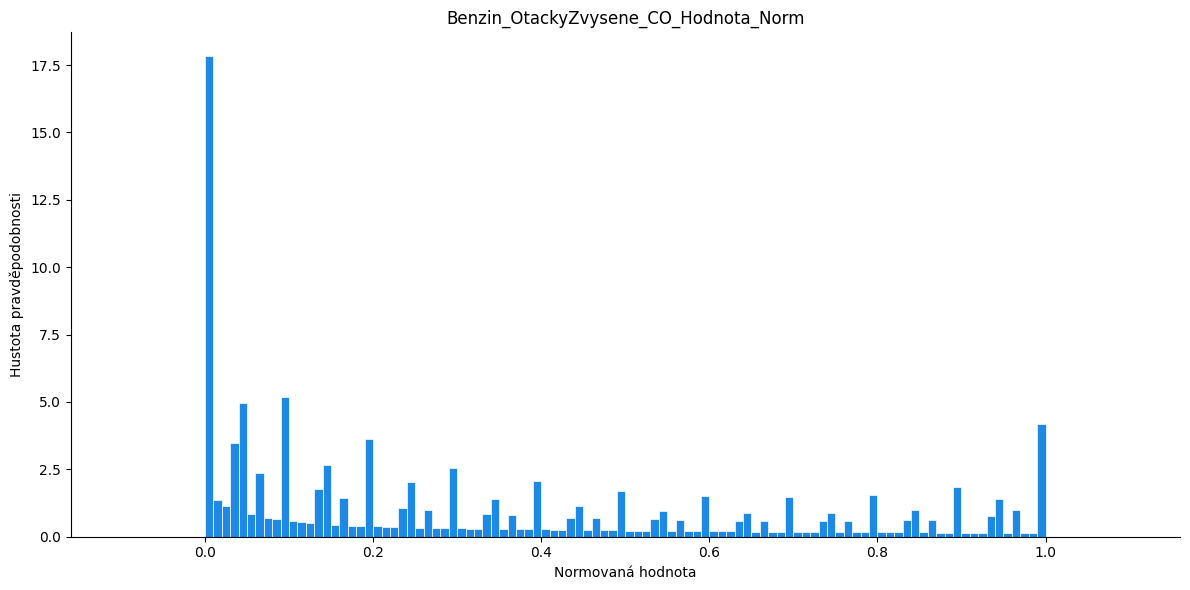

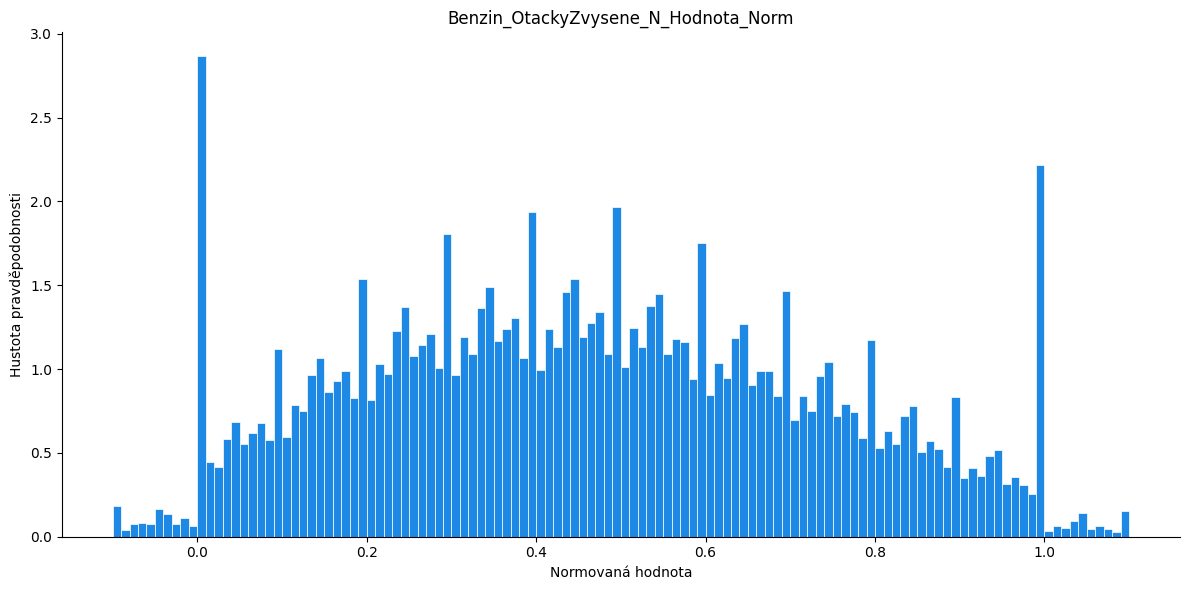

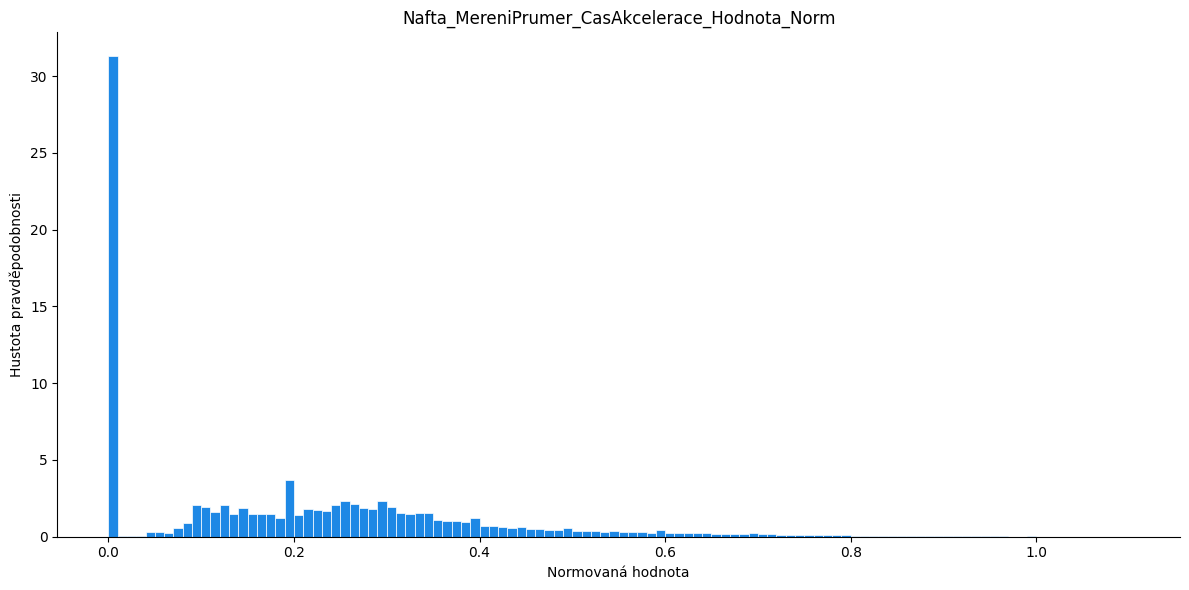

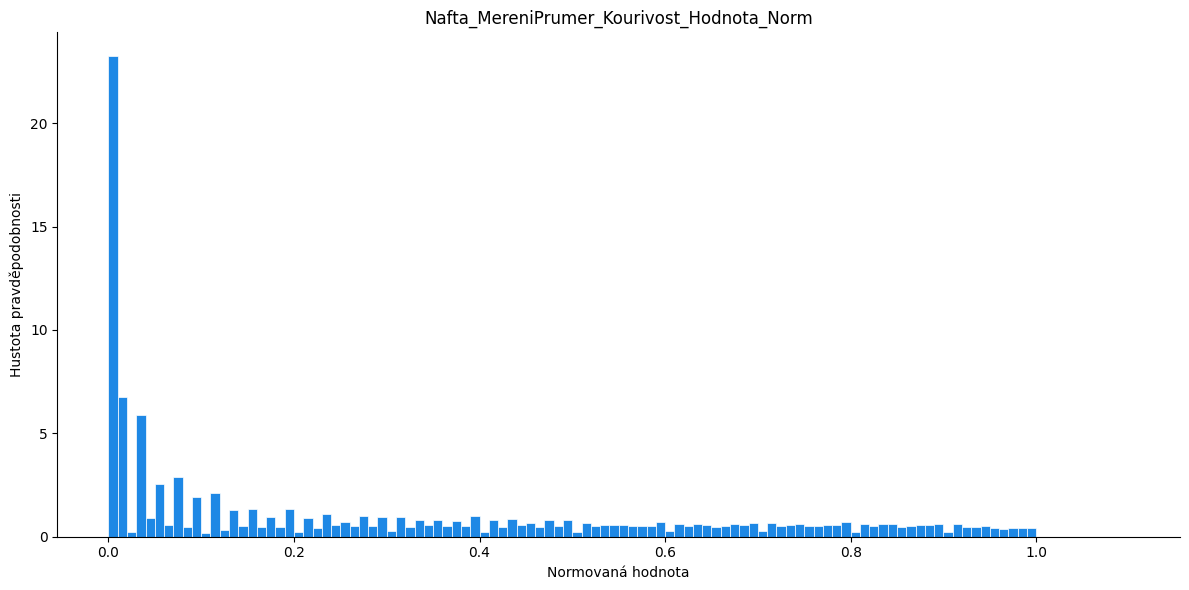

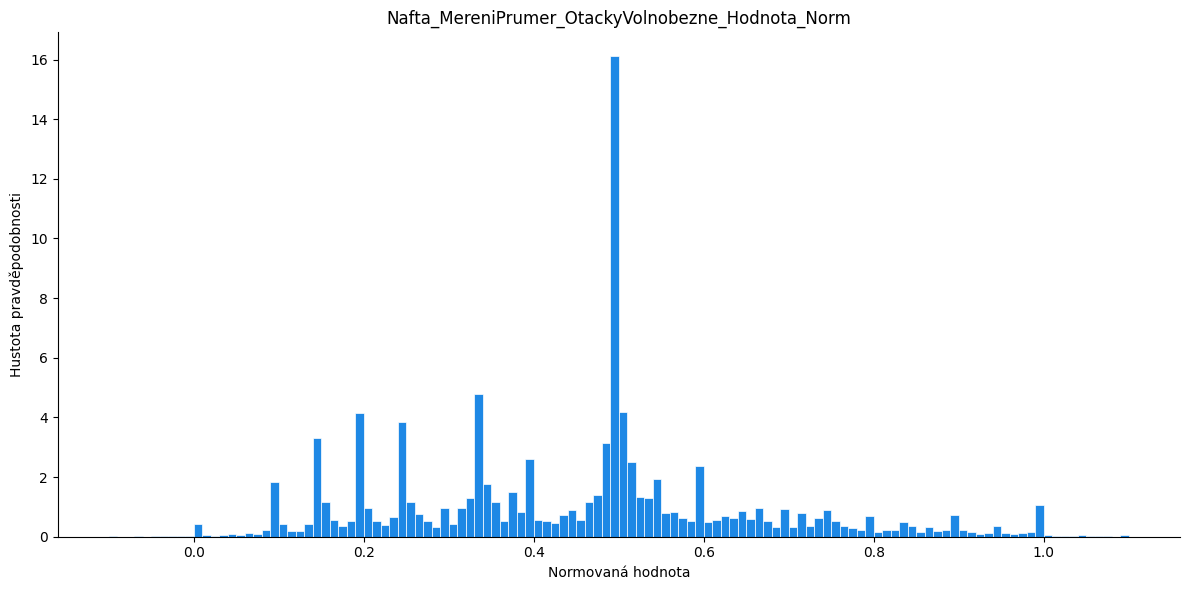

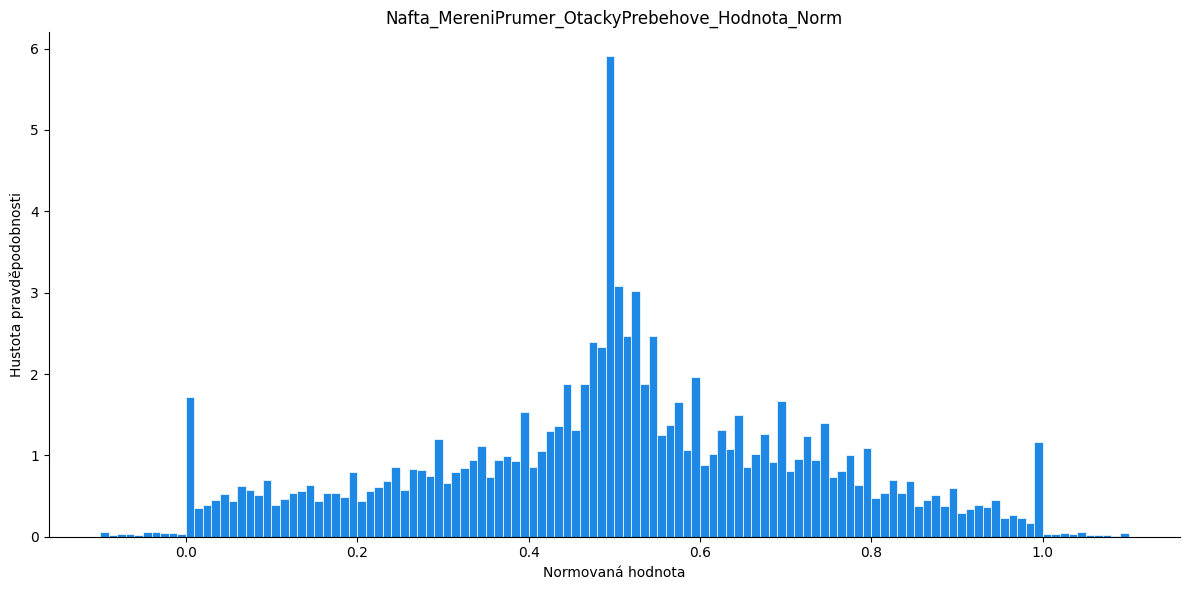

In [102]:
def plot_norms(df):
    for col in df.columns:
        distribution_density_plot(df.filter(pl.col(col).is_between(-0.1, 1.1)), col, col, 'Normovaná hodnota', 100, (0, 1.00001))
plot_norms(df_benzin)
plot_norms(df_nafta)

# Finální příprava pro tvorbu modelu

## Sparovani pristich vysledku s merenimi

In [103]:
lf_full = pl.scan_parquet(r'kod\data\extracted\data_z_mericich_pristroju\parquet', schema=mereni_schema).pipe(cast_mereni)

lf_shifted_result = (
    lf_full
    .select(["CisloProtokolu", "Vozidlo_Vin", "Zahajeni", "Vysledek_Vyhovuje"])
    .sort(["Vozidlo_Vin", "Zahajeni"])
    .with_columns(
        Vysledek_Pristi_Raw=pl.col("Vysledek_Vyhovuje").shift(-1).over("Vozidlo_Vin"),
        Pristi_Zaznam_Existuje=pl.col("CisloProtokolu").shift(-1).over("Vozidlo_Vin").is_not_null()
    )
    .with_columns(
        Vysledek_Pristi=pl.when(pl.col("Pristi_Zaznam_Existuje"))
        .then(pl.col("Vysledek_Pristi_Raw").fill_null(False))
        .otherwise(None)
    )
    .select(["CisloProtokolu", "Vysledek_Pristi"])
)

df = (
    df.lazy()
    .join(
        lf_shifted_result,
        on="CisloProtokolu",
        how="left"
    )
    .collect()
)

## Odstraneni mereni, ktera nemaji znamy pristi vysledek

In [104]:
if PRINT: display(df['Vysledek_Pristi'].value_counts())
df = df.filter(pl.col('Vysledek_Pristi').is_not_null())

Vysledek_Pristi,count
bool,u32
false,256922
true,9451280
null,5689363


# Ulozeni dat pro trenovani modelu

In [105]:
df.write_parquet(r"kod\data\processed\mereni_model.parquet")

In [107]:
PRINT = True
if PRINT: describe(df)

CisloProtokolu,Vysledek_VisualniKontrola,Vysledek_Readiness,Vysledek_RidiciJednotkaStav,Vysledek_Mil,Obd_Readiness_Vysledek,Zavady,Poznamky,OBD_Pritomno,Obd_KomunikacniProtokol,Obd_KontrolaMil,Obd_PocetDtc,Benzin_PocetVyusteni,Nafta_PocetVyusteni,Benzin_OtackyVolnobezne_CO_Hodnota_Norm,Benzin_OtackyVolnobezne_N_Hodnota_Norm,Benzin_OtackyZvysene_LAMBDA_Hodnota_Norm,Benzin_OtackyZvysene_CO_Hodnota_Norm,Benzin_OtackyZvysene_N_Hodnota_Norm,Nafta_MereniPrumer_CasAkcelerace_Hodnota_Norm,Nafta_MereniPrumer_Kourivost_Hodnota_Norm,Nafta_MereniPrumer_OtackyVolnobezne_Hodnota_Norm,Nafta_MereniPrumer_OtackyPrebehove_Hodnota_Norm,MericiPristroj_Info,Pocet_Podporovano,Pocet_Otestovano,Vysledek_Pristi
str,bool,bool,i8,i8,bool,u32,u32,bool,str,i8,i32,i8,i8,f32,f32,f32,f32,f32,f32,f32,f32,f32,str,u32,u32,bool
"""CZ-410822-21-07-0217""",true,null,1,2,null,0,2,false,null,null,null,0,1,null,null,null,null,null,0.0,0.909091,0.56,0.542308,"""ActiaCZAT605""",0,0,true


(9708202, 27)


,CisloProtokolu,Vysledek_VisualniKontrola,Vysledek_Readiness,Vysledek_RidiciJednotkaStav,Vysledek_Mil,Obd_Readiness_Vysledek,Zavady,Poznamky,OBD_Pritomno,Obd_KomunikacniProtokol,...,Benzin_OtackyZvysene_CO_Hodnota_Norm,Benzin_OtackyZvysene_N_Hodnota_Norm,Nafta_MereniPrumer_CasAkcelerace_Hodnota_Norm,Nafta_MereniPrumer_Kourivost_Hodnota_Norm,Nafta_MereniPrumer_OtackyVolnobezne_Hodnota_Norm,Nafta_MereniPrumer_OtackyPrebehove_Hodnota_Norm,MericiPristroj_Info,Pocet_Podporovano,Pocet_Otestovano,Vysledek_Pristi
0,CZ-410822-21-07-0217,True,None,1.0,2.0,None,0,2,False,None,...,NaN,NaN,0.000,0.909091,0.560000,0.542308,ActiaCZAT605,0,0,True
1,CZ-480768-22-04-0017,True,True,1.0,2.0,True,0,1,True,ISO 15765,...,0.095000,0.703333,NaN,NaN,NaN,NaN,BoschBEA055,7,7,True
2,CZ-411005-21-09-0038,True,True,1.0,2.0,True,0,1,True,CAN (ISO 15765-4),...,0.935000,0.656000,NaN,NaN,NaN,NaN,BOSCHBEA450,7,11,True
3,CZ-410907-19-04-0159,True,True,1.0,2.0,True,0,2,True,ISO 15765,...,NaN,NaN,0.166,0.113208,0.500000,0.433333,AVL DiTEST GmbHAVL DiSmoke 480,1,11,True
4,CZ-461132-21-12-0149,True,None,1.0,2.0,None,0,5,False,None,...,0.500000,0.210000,NaN,NaN,NaN,NaN,ACTIA CZ s.r.o.AT505,0,0,True
5,CZ-480534-22-04-0868,True,True,1.0,2.0,True,0,4,True,ISO 15765,...,0.450000,0.230000,NaN,NaN,NaN,NaN,AVL DiTEST GmbHAVL Gas 1000,6,11,True
6,CZ-570521-23-10-0334,True,True,1.0,2.0,True,0,1,True,ISO 14230,...,NaN,NaN,0.378,0.215686,0.560000,0.846512,BoschBEA 950,3,11,True
7,CZ-481020-24-01-0334,True,True,1.0,2.0,True,0,1,True,ISO 14230,...,NaN,NaN,0.316,0.814286,0.355000,0.235000,BoschBEA 950,3,11,True
8,CZ-470811-21-03-0141,True,True,1.0,2.0,True,0,3,True,ISO9141,...,NaN,NaN,0.000,0.000000,0.320000,0.507500,BRAIN BEEOPA-100,6,11,True
9,CZ-130102-23-07-0278,True,True,1.0,2.0,True,0,5,True,ISO 15765,...,0.500000,0.199231,NaN,NaN,NaN,NaN,ATAL s.r.o.AT505,5,11,True


,column,majority_class,majority_cnt,null,dtype
0,CisloProtokolu,CZ-420620-21-10-0387,2 / 9 708 202,0 / 9 708 202,String
1,Vysledek_VisualniKontrola,True,9 707 601 / 9 708 202,0 / 9 708 202,Boolean
2,Vysledek_Readiness,True,6 849 224 / 9 708 202,1 382 228 / 9 708 202,Boolean
3,Vysledek_RidiciJednotkaStav,1,9 321 684 / 9 708 202,313 099 / 9 708 202,Int8
4,Vysledek_Mil,2,9 280 573 / 9 708 202,423 181 / 9 708 202,Int8
5,Obd_Readiness_Vysledek,True,7 783 724 / 9 708 202,1 452 671 / 9 708 202,Boolean
6,Zavady,0,9 700 670 / 9 708 202,0 / 9 708 202,UInt32
7,Poznamky,2,3 286 247 / 9 708 202,0 / 9 708 202,UInt32
8,OBD_Pritomno,True,8 255 531 / 9 708 202,0 / 9 708 202,Boolean
9,Obd_KomunikacniProtokol,ISO 15765,3 389 897 / 9 708 202,1 452 671 / 9 708 202,String


## Prevedeni vsech sloupcu do cisel

In [ ]:
# EmisniSystem uz obsahoval pouze 2 hodnoty
df = df.with_columns(pl.col('EmisniSystem') == 'Rizeny_Obd').rename({'EmisniSystem': 'OBD_Pritomno'})

In [79]:
df

CisloProtokolu,Vysledek_VisualniKontrola,Vysledek_Readiness,Vysledek_RidiciJednotkaStav,Vysledek_Mil,Obd_Readiness_Vysledek,Zavady,Poznamky,OBD_Pritomno,Obd_KomunikacniProtokol,Obd_KontrolaMil,Obd_PocetDtc,Benzin_PocetVyusteni,Nafta_PocetVyusteni,Benzin_OtackyVolnobezne_CO_Hodnota_Norm,Benzin_OtackyVolnobezne_N_Hodnota_Norm,Benzin_OtackyZvysene_LAMBDA_Hodnota_Norm,Benzin_OtackyZvysene_CO_Hodnota_Norm,Benzin_OtackyZvysene_N_Hodnota_Norm,Nafta_MereniPrumer_CasAkcelerace_Hodnota_Norm,Nafta_MereniPrumer_Kourivost_Hodnota_Norm,Nafta_MereniPrumer_OtackyVolnobezne_Hodnota_Norm,Nafta_MereniPrumer_OtackyPrebehove_Hodnota_Norm,MericiPristroj_Info,Pocet_Podporovano,Pocet_Otestovano,Vysledek_Pristi
str,bool,bool,i8,i8,bool,u32,u32,bool,str,i8,i32,i8,i8,f32,f32,f32,f32,f32,f32,f32,f32,f32,str,u32,u32,bool
"""CZ-410822-21-07-0217""",true,null,1,2,null,0,2,false,null,null,null,0,1,null,null,null,null,null,0.0,0.909091,0.56,0.542308,"""ActiaCZAT605""",0,0,true
"""CZ-480768-22-04-0017""",true,true,1,2,true,0,1,true,"""ISO 15765""",2,0,1,0,0.0,0.245,0.466667,0.095,0.703333,null,null,null,null,"""BoschBEA055""",7,7,true
"""CZ-411005-21-09-0038""",true,true,1,2,true,0,1,true,"""CAN (ISO 15765-4)""",2,0,1,0,0.006667,0.495,0.55,0.935,0.656,null,null,null,null,"""BOSCHBEA450""",7,11,true
"""CZ-410907-19-04-0159""",true,true,1,2,true,0,2,true,"""ISO 15765""",2,0,0,1,null,null,null,null,null,0.166,0.113208,0.5,0.433333,"""AVL DiTEST GmbHAVL DiSmoke 480""",1,11,true
"""CZ-461132-21-12-0149""",true,null,1,2,null,0,5,false,null,null,null,1,0,0.5,0.6,0.975002,0.5,0.21,null,null,null,null,"""ACTIA CZ s.r.o.AT505""",0,0,true
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""CZ-411033-19-01-0257""",true,true,1,2,true,0,2,true,"""ISO 15765""",2,0,1,0,0.0,0.5,0.5,0.0,1.108,null,null,null,null,"""ActiaCZAT505""",7,11,true
"""CZ-120301-21-05-0448""",true,false,1,2,true,0,2,true,"""ISO 9141""",2,0,1,0,0.1,0.25,0.566666,0.1,0.95,null,null,null,null,"""AVL DiTEST GmbHAVL Gas 1000""",8,10,true
"""CZ-460513-21-03-0136""",true,false,1,2,true,0,3,true,"""CAN (ISO 15765-4)""",2,0,0,1,null,null,null,null,null,0.0,0.0,0.245,0.5725,"""BoschBEA070""",6,7,true
